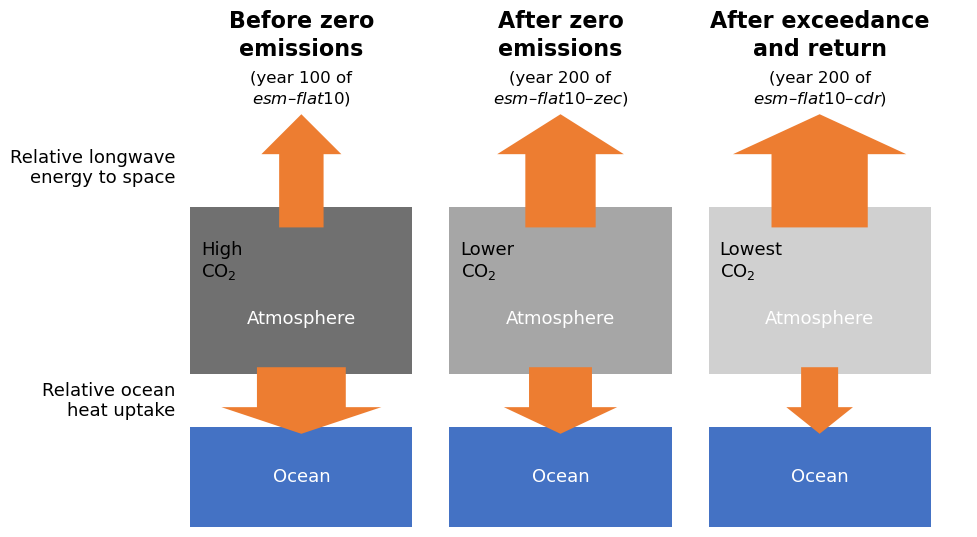

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 5.5))

# Panel definitions: (title, atmosphere_color, atmosphere_text, up_arrow_width, down_arrow_width)
panels = [
    ("Before zero\nemissions", "(year 100 of\n$\mathit{esm}\t{–}\mathit{flat10}$)", "#707070", "High\nCO$_2$", 0.6, 1.2),
    ("After zero\nemissions", "(year 200 of\n$\mathit{esm}\t{–}\mathit{flat10}\t{–}\mathit{zec}$)", "#A6A6A6", "Lower\nCO$_2$", 0.95, 0.85),
    ("After exceedance\nand return", "(year 200 of\n$\mathit{esm}\t{–}\mathit{flat10}\t{–}\mathit{cdr}$)", "#D0D0D0", "Lowest\nCO$_2$", 1.3, 0.5),
]

ocean_color = "#4472C4"
arrow_color = "#ED7D31"

box_width = 3.0
box_height_atm = 2.5
box_height_ocean = 1.5
atm_y = 3.0
ocean_y = 0.7
panel_spacing = 3.5

for i, (title, subtitle, atm_color, atm_text, up_w, down_w) in enumerate(panels):
    x0 = i * panel_spacing

    # Title
    ax.text(x0 + box_width / 2, 7.7, title, ha="center", va="bottom",
             fontsize=16, linespacing=1.3, fontweight='bold')

    ax.text(x0 + box_width / 2, 7, subtitle, ha="center", va="bottom",
             fontsize=12, linespacing=1.3)

    # Atmosphere box
    ax.add_patch(patches.Rectangle((x0, atm_y), box_width, box_height_atm,
                                     facecolor=atm_color, edgecolor="none"))
    ax.text(x0 + 0.15, atm_y + box_height_atm - 0.5, atm_text,
            ha="left", va="top", fontsize=13, color="black")
    ax.text(x0 + box_width / 2, atm_y + 0.7, "Atmosphere",
            ha="center", va="bottom", fontsize=13, color="white")

    # Ocean box
    ax.add_patch(patches.Rectangle((x0, ocean_y), box_width, box_height_ocean,
                                     facecolor=ocean_color, edgecolor="none"))
    ax.text(x0 + box_width / 2, ocean_y + box_height_ocean / 2, "Ocean",
            ha="center", va="center", fontsize=13, color="white")

    # Upward arrow (from atmosphere top upward)
    arrow_cx = x0 + box_width / 2
    ax.add_patch(patches.FancyArrow(
        arrow_cx, atm_y + box_height_atm - 0.3, 0, 1.7,
        width=up_w, head_width=up_w * 1.8, head_length=0.6,
        length_includes_head=True, facecolor=arrow_color, edgecolor="none"))

    # Downward arrow (from atmosphere bottom to ocean)
    ax.add_patch(patches.FancyArrow(
        arrow_cx, atm_y + 0.1, 0, -(box_height_atm - ocean_y - box_height_ocean + 0.7),
        width=down_w, head_width=down_w * 1.8, head_length=0.4,
        length_includes_head=True, facecolor=arrow_color, edgecolor="none"))

# Left-side labels (once, aligned with first panel's arrows)
ax.text(-0.2, atm_y + box_height_atm + 0.6, "Relative longwave\nenergy to space",
        ha="right", va="center", fontsize=13)
ax.text(-0.2, atm_y - 0.4, "Relative ocean\nheat uptake",
        ha="right", va="center", fontsize=13)

ax.set_xlim(-1.5, panel_spacing * 2 + box_width + 0.5)
ax.set_ylim(0.7, 8)
ax.axis("off")
plt.tight_layout()
plt.savefig('fig_energy_schematic.png', dpi=300, bbox_inches='tight')
